# **Project Title:**

**"Data Analysis and Visualization of Indian ODI Cricketers using Python"**

---

### **Key Learning Objectives)**


1. **Use Python libraries for data analysis and visualization**

   * Work with `pandas`, `numpy`, `matplotlib`, `seaborn`, and `scipy.stats`.

2. **Read, clean, and preprocess CSV data**

   * Load data from an online URL.
   * Rename columns, convert date strings to years, and handle missing values.

3. **Transform raw data into meaningful features**

   * Calculate age from birth year.
   * Group data into cohorts and city size categories.

4. **Perform basic statistical analysis**

   * Use descriptive statistics and correlation matrices.
   * Run Welch's t-tests using `scipy`.

5. **Build insightful visualizations**

   * Create bar plots, box plots, scatter plots, and regression plots.
   * Customize themes and styles with `matplotlib` and `seaborn`.

6. **Interpret data-driven insights**

   * Learn to explain plots and numerical results in plain English.
   * Form actionable recommendations based on visual patterns.

---

### **Project Overview**

This project uses a dataset of Indian ODI cricketers to explore:

* How birth year, city size, and role (batsman, bowler, etc.) influence career outcomes.
* Whether certain roles or cities produce more long-serving players.
* Trends in ODI appearances by age group and player background.

Write a Python script that:

* Loads player data from an online `.csv` file.
* Prepares and enriches the data (e.g., calculates age and groups birth years).
* Visualizes key trends using horizontal bar charts, facet plots, and boxplots.
* Runs statistical comparisons (e.g., between batsmen and all-rounders).
* Outputs visual and numeric insights that could help selectors or analysts.

### Import Libraries
---

#### 1  `import numpy as np`

*“First, let’s grab **NumPy** and give it the nickname **np**.”*

NumPy is the fast-math engine of Python: it stores numbers in compact arrays and can add, subtract, multiply, etc., on whole columns in one go. By writing `np` instead of the longer `numpy`, we save typing every time we call a NumPy function (`np.mean()`, `np.arange()`, …).

---

#### 2  `import pandas as pd`

*“Next, bring in **pandas** and shorten it to **pd**.”*

Pandas adds the spreadsheet-like **DataFrame** to Python. Whenever you need rows, columns, and labels—just like in Excel—you’ll reach for `pd`. Aliasing to `pd` is the community’s unwritten rule, so all examples you see online will match what you type.

---

#### 3  `import matplotlib.pyplot as plt`

*“Now we import **matplotlib’s** plotting window and call it **plt**.”*

`pyplot` is a bit like the paintbrush: it creates figures, axes, lines, bars, and so on. The alias `plt` is a convenience handle: `plt.plot()`, `plt.title()`, `plt.show()`.

---

#### 4  `import seaborn as sns`

*“On top of matplotlib we layer **Seaborn**, giving it the short name **sns**.”*

Seaborn makes prettier, statistically-aware graphs with a single call—things like `sns.boxplot()` or `sns.heatmap()`. It still draws on matplotlib underneath, so both libraries play nicely together.

---

#### 5  `from pathlib import Path`

*“File paths can be messy—different slashes on Windows, macOS, Linux. **Pathlib’s** `Path` class smooths that out.”*

Instead of juggling raw strings like `"C:\\Users\\me\\file.csv"`, we build paths the clean, OS-independent way:

```python
data_dir = Path("data") / "inputs"
```

It feels like Lego blocks snapping together.

---

#### 6  `from scipy import stats`

*“Finally, pull in the `stats` toolbox from **SciPy**.”*

SciPy is a giant collection of scientific utilities. The `stats` sub-module gives you t-tests, correlations, probability distributions—everything you’d normally hunt for in a statistics package. Importing just this sub-module keeps the namespace tidy: you’ll write `stats.ttest_ind()` instead of `scipy.stats.ttest_ind()`.

---

With these six lines you’ve loaded the key ingredients for most data-analysis recipes in Python: fast number crunching (`np`), tabular data wrangling (`pd`), plotting (`plt` + `sns`), file management (`Path`), and statistics (`stats`).


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats

### Chart Settings

* You **set-and-forget** the look-and-feel, so every chart that follows is automatically consistent.
* You can stop wasting time tweaking sizes for every single plot and can focus on *analysis*.

---

#### 1  `plt.rcParams["figure.figsize"] = (9, 6)`

1. **`plt`**
   This is our nickname for `matplotlib.pyplot`—the drawing canvas we imported earlier.

2. **`rcParams`**
   Think of `rcParams` as a big dictionary where Matplotlib stores all its default style rules (font sizes, colours, grid visibility, etc.). “rc” historically means *run-command* parameters.

3. **`["figure.figsize"]`**
   We’re picking one specific rule: the *default* width and height (in inches) of every figure we create.

4. **`= (9, 6)`**
   Here we overwrite that default, telling Matplotlib:
   *“Hey, whenever I call `plt.figure()` (or any plotting function that makes a figure for me), make it **9 inches wide and 6 inches tall**.”*
   Bigger canvas → more room for labels and grids; no need to re-specify the size in every plot.

---

#### 2  `sns.set_theme(style="whitegrid", rc={"axes.titlesize": 16, "axes.labelsize": 13})`

1. **`sns`**
   That’s Seaborn, our higher-level styling helper.

2. **`.set_theme(...)`**
   `set_theme` flips the global styling switches for *all* subsequent Seaborn **and** Matplotlib plots. One call, theme everywhere.

3. **`style="whitegrid"`**
   We choose Seaborn’s *whitegrid* style: white background, light grey grid lines. Great for data-heavy visualisations because the grid helps the eye track values.

4. **`rc={...}`**
   The `rc` keyword lets us pass a mini-dictionary of extra Matplotlib rules to tweak on top of the theme.

   * **`"axes.titlesize": 16`**
     Bump the default axis-title font to 16 pt—large enough to stand out.

   * **`"axes.labelsize": 13`**
     Set x- and y-axis label fonts to 13 pt—readable but not overwhelming.

In [2]:
plt.rcParams["figure.figsize"] = (9, 6)
sns.set_theme(style="whitegrid", rc={"axes.titlesize": 16, "axes.labelsize": 13})

### Load CSV File

---

#### `url = "https://samatrix-data.s3.ap-south-1.amazonaws.com/Statistics-Project/odi-cricket-player.csv"`

1. **`url`** — We’re creating a new variable and calling it **`url`**; the name reminds us that it will hold a web address.
2. **`=`** — Assignment operator: “store the thing on the right-hand side in the variable on the left.”
3. **The long text in quotes** — A plain **string** containing the full HTTPS link to a CSV file sitting on an Amazon S3 bucket.

   * Nothing special about the quotes—it’s just text.
   * Because it starts with `https://`, Pandas (and most browsers) recognise it as a web address.

*End result:* the variable `url` now points to the exact online location of our dataset.

---

#### `df = pd.read_csv(url)`

1. **`pd.read_csv(` … `)`**

   * `pd` is our shorthand for the **pandas** library.
   * `read_csv` is a built-in pandas function that knows how to open a CSV file and turn it into a tidy **DataFrame**.
2. **`url`**

   * We pass the variable we just made.
   * Pandas sees the string starts with `http`/`https`, so it automatically downloads the file, reads it, and parses it—no extra code needed.
3. **`df =`**

   * We capture the returned DataFrame—rows and columns neatly organised—and store it in a variable called **`df`** (short for *dataframe*).


`df` now contains the entire table from that online CSV, ready for filtering, plotting, or analysis—with just two lines of code.


In [33]:
url = "https://samatrix-data.s3.ap-south-1.amazonaws.com/Statistics-Project/odi-cricket-player.csv"
df = pd.read_csv(url)

### Check the Data Set

* **Quick sanity check:** Did the file load? Do the columns look as expected?
* **Know your playground:** Rows and columns tell you how much data you’re dealing with, helping you gauge performance concerns or sampling decisions.

---

#### 1  `print("\nFirst five rows \n", df.head())`

1. **`print(`**
   We’re asking Python to spit something out to the screen.

2. **`"\nFirst five rows \n"`**

   * `\n` is a *newline*—it forces the cursor to drop to the next line so the output isn’t crammed against whatever came before.
   * The text *First five rows* is just a friendly label so we know what we’re about to see.
   * Another `\n` adds a blank line after the label for readability.

3. **`,`** *(comma inside print)*
   Separates the label text from the next thing we want to print.

4. **`df.head()`**

   * `df` is our DataFrame.
   * `.head()` is a built-in Pandas method that returns the **first five rows** by default.
   * Great way to eyeball whether the file loaded correctly: column names, sample values, no weird misalignments.

So that whole line prints a heading, then the first five rows of the table.

---

#### 2  `print("\nDataFrame shape:", df.shape)`

1. **`print(`**
   Another line of output coming up.

2. **`"\nDataFrame shape:"`**

   * Starts with `\n` to ensure we’re on a fresh line.
   * The phrase *DataFrame shape:* tells us what the number that follows actually represents.

3. **`,`**
   Separates the label from the value we’re about to display.

4. **`df.shape`**

   * `.shape` is a *property* (no parentheses) that returns a **tuple**: `(row_count, column_count)`.
   * For example, `(1000, 12)` means 1,000 rows and 12 columns.

So this second line prints how big the dataset is—both dimensions at once.

In [34]:
print("\nFirst five rows \n", df.head())
print("\nDataFrame shape:", df.shape)


First five rows 
    Index     Player_name Birthplace  \
0      1  Shikhar Dhawan      Delhi   
1      2    Rohit Sharma     Nagpur   
2      3     K. L. Rahul  Bangalore   
3      4     Virat Kohli      Delhi   
4      5        MS Dhoni     Ranchi   

                                         Census_info  population      class  \
0   Delhi U.A [DEL, Population: 12877470, Class - I]    12877470  Class - I   
1  Nagpur UA [ MAH, Population: 2129500, Class - I ]     2129500  Class - I   
2  Bangalore UA [ KRN, Population: 5701446, Class...     5701446  Class - I   
3   Delhi U.A [DEL, Population: 12877470, Class - I]    12877470  Class - I   
4     Ranchi UA [JHA, Population: 863495, Class - I]      863495  Class - I   

                                       Census_url        State  \
0  https://censusindia.gov.in/towns/del_towns.pdf        Delhi   
1  https://censusindia.gov.in/towns/mah_towns.pdf  Maharashtra   
2  https://censusindia.gov.in/towns/krn_towns.pdf    Karnataka   
3  http

### Basic Cleaning and Enrichment

We’ve replaced those long or oddly-cased column names with short, tidy ones—making life easier for all the code that follows.

---

### `df = df.rename(`

*“Take our DataFrame `df` and **rename** some columns, then save the result back into `df`.”*

> Pandas’ `rename()` function doesn’t change the original table unless you either set `inplace=True` or, as we’re doing here, assign the returned copy back to the same variable.

---

### `columns={ ... },`

*“Here comes a **dictionary** of rename rules.”*
The word **columns** tells Pandas that the keys and values inside the curly braces refer to column names (you could also rename index labels with the `index=` argument).

---

| Old name                  | → | New name        | Why?                                         |
| ------------------------- | - | --------------- | --------------------------------------------------- |
| `"Number_of_ODIs_played"` | → | `"odis_played"` | Short, lowercase, snake-case—easy to type and read. |
| `"Major_contribution"`    | → | `"role"`        | Even shorter; “role” tells us the same thing.       |
| `"Birth_year"`            | → | `"birth_year"`  | Just fix the capital “B”; consistency matters.      |

*(Keys = current names in the CSV, Values = names we actually want.)*

---

### `errors="ignore"`

*“If any of those old column names don’t exist, **don’t crash**—just skip them.”*
Useful when you’re not 100 % sure every file you load will have the exact same columns.

---

### `)`  *(closing parenthesis)*

Ends the `rename()` call. At this point the method returns a brand-new DataFrame with the cleaner column names, and we store it back in `df` so every later command uses the updated labels.

In [5]:
# --------------------- Basic cleaning & enrichment ------------------------
df = df.rename(
    columns={
        "Number_of_ODIs_played": "odis_played",
        "Major_contribution": "role",
        "Birth_year": "birth_year",
    },
    errors="ignore"
)

### Missing Data

---

####  `df[["birth_year", "odis_played", "population", "State", "role"]]`

*“First, let’s grab a **subset** of our table.”*

* `df` is the whole DataFrame.
* The double brackets `[[...]]` hold a list of the five columns we care about.
  We’re ignoring every other column for this check.

---

####  `.isna()`

*“Now we ask Pandas: ‘Which cells in that mini-table are **missing**?’ ”*

* `isna()` returns a new DataFrame of the same shape, but every entry is
  `True` if the original cell was `NaN` (blank, NULL, etc.) and `False` otherwise.
  Think of it as a **mask** that highlights the empty spots.

---

####  `.sum()`

*“Let’s **count** how many `True`s we just found in each column.”*

* In Pandas, `True` behaves like the number `1` and `False` like `0`.
* So summing down each column totals up the missing values.
  The result is a **Series** that looks something like:

  ```
  birth_year      3
  odis_played     0
  population      2
  State           0
  role            1
  dtype: int64
  ```

---

####  `print( ... )`

*“Finally, spit those counts to the screen so we can actually see them.”*

* The print lets us eyeball which columns need cleaning:
  *“Ah—three blank birth years, two missing populations…”*

In [6]:
print(df[["birth_year", "odis_played", "population", "State", "role"]].isna().sum())

birth_year     0
odis_played    0
population     0
State          0
role           0
dtype: int64


### View Missing Data Closely

> “Find every row that’s missing *anything* in birth year, ODIs played, population, state, or role, save those rows in `bad`, and show me the first five so I can take a closer look.”

---

#### 1.  `df[ ["birth_year", … "role"] ]`

*“Start by taking just five columns out of our whole table.”*

The result is a **mini-DataFrame** containing only those columns.

---

#### 2.  `.isna()`

*“Mark every cell that’s blank.”*

This converts the mini-DataFrame into `True`/`False` flags — `True` where the data is missing.

---

#### 3.  `.any(axis=1)`

*“For each row, ask: *‘Does this row have **any** blanks?’* ”*

* `axis=1` means “look **across** the columns in each row.”
* The outcome is a **one-column Series** of booleans:
  `True` if the row has at least one missing value in those five columns, `False` otherwise.

---

#### 4.  `df[  <mask>  ]`

*“Use that Series of booleans as a **mask** to filter the original DataFrame.”*

* Rows where the mask is `True` (bad rows) are kept.
* Rows where the mask is `False` (good rows) are dropped.
* The filtered result is stored in the new variable **`bad`**.

---

#### 5.  `print(bad.head())`

*“Show me the first few of those ‘bad’ rows so I can inspect what’s wrong.”*

`head()` grabs the top five; printing them lets you see which fields are empty and decide how to fix them.

In [7]:
bad = df[df[["birth_year", "odis_played", "population", "State", "role"]].isna().any(axis=1)]
print(bad.head())

Empty DataFrame
Columns: [Index, Player_name, Birthplace, Census_info, population, class, Census_url, State, birth_year, Major contribution (ORIG), role, odis_played, Player_url, Latitude (ORIG), Longitude (ORIG), Latitude, Longitude, Player_image]
Index: []


### Convert the Messey Dates to Year

1. **Convert** the messy text dates into true datetime objects (`pd.to_datetime`).
2. **Extract** only the year part (`.dt.year`) and save it back, so the *birth\_year* column is now clean, consistent numbers ready for analysis.

#### Line 1 `dt = pd.to_datetime(df["birth_year"], errors="coerce")`

| Piece                 | What I’d say out loud                                                                                                                       |
| --------------------- | ------------------------------------------------------------------------------------------------------------------------------------------- |
| `df["birth_year"]`    | “Grab the *birth\_year* column. Right now it’s full of text like **‘November 5, 1988’**.”                                                   |
| `pd.to_datetime( … )` | “Ask Pandas to **translate those text dates into real timestamp objects** that Python understands.”                                         |
| `errors="coerce"`     | “If Pandas sees a weird or blank entry it can’t decode, don’t crash—just turn it into **NaT** (Not-a-Time, the datetime version of NaN).”   |
| `dt = …`              | “Store the cleaned-up result in a new variable called **dt**. Think of *dt* as a temporary scratch pad—we’ll use it in the very next line.” |

After this step, `dt` is a Series of proper datetime values:

```
0   1988-11-05
1   1992-07-14
2          NaT
dtype: datetime64[ns]
```

---

#### Line 2 `df["birth_year"] = dt.dt.year`

| Piece                  | Explanation                                                                       |
| ---------------------- | ------------------------------------------------------------------------------------------- |
| `dt.dt`                | “Access the **datetime accessor** (`.dt`) that lets us pick apart parts of each timestamp.” |
| `.year`                | “From every full date, pull out **just the four-digit year**—1988, 1992, and so on.”        |
| `df["birth_year"] = …` | “Overwrite the original *birth\_year* column with those pure year numbers.”                 |

So `"November 5, 1988"` becomes simply `1988`. Any `NaT` entries turn into `NaN`, keeping the column numeric while still marking unknown years.

In [8]:
dt = pd.to_datetime(df["birth_year"], errors="coerce")
df["birth_year"] = dt.dt.year

### Convert numeric columns that were read as object

1. Make a list of the columns that ought to be numeric.
2. Loop through that list.
3. Inside the loop, force each column to become clean, machine-readable numbers, safely turning any bad entries into blanks (`NaN`).

---

```python
numeric_cols = ["odis_played", "population"]
```

*“First, make a little list called **numeric\_cols**.”*

* The list contains the names of the columns that **should be numbers**:
  `odis_played` (how many one-day internationals a player has) and
  `population` (size of the player’s birthplace city).
* Putting the names in a list means we can loop over them instead of writing the same code twice.

---

```python
for col in numeric_cols:
```

*“Now start a **for-loop** that will run once for each column name in that list.”*

* On the first pass, `col` equals `"odis_played"`.
* On the second pass, `col` equals `"population"`.
* Anything we indent underneath will happen for both columns, one at a time.

---

```python
    df[col] = pd.to_numeric(df[col], errors="coerce")
```

*(Inside the loop, four things happen in one tidy line.)*

1. **`df[col]`**

   * Grab the column currently stored in `col`.
     If `col` is `"odis_played"`, we’re looking at `df["odis_played"]`.

2. **`pd.to_numeric( … )`**

   * Ask Pandas to **convert every entry in that column into a real number** (integers or floats).
   * It strips out stray commas, spaces, and other non-numeric characters.

3. **`errors="coerce"`**

   * “If Pandas runs into a value it can’t turn into a number—like the word `'N/A'`—don’t crash.
     Instead, turn that value into `NaN` (Not-a-Number), which Pandas treats as a blank.”

4. **`df[col] = …`**

   * Drop the cleaned, numeric version right back into the DataFrame, replacing the old messy strings.

In [9]:
# Convert numeric columns that were read as object

numeric_cols = ["odis_played", "population"]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

### Drop rows without essential data

> *“Keep only the rows that have complete information for year of birth, ODI count, city population, state, and player role.”*

This prevents later calculations from tripping over missing values in the columns we absolutely need.

---

```python
df = df.dropna(
        subset=["birth_year", "odis_played", "population", "State", "role"]
     )
```

| Part                | Explanation                                                                                                                                                     |
| ------------------- | ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **`df`**            | Our whole table of cricket data.                                                                                                                                                   |
| **`.dropna(`**      | “Make me a copy of this table **without rows that have blanks**.” (`na` = *not available*).                                                                                        |
| **`subset=[ … ]`**  | “But only worry about **these five critical columns**. I don’t care if other columns are missing.”<br>• `birth_year`<br>• `odis_played`<br>• `population`<br>• `State`<br>• `role` |
| *(end of `dropna`)* | The method produces a **new** DataFrame where any row that had a `NaN` in *any* of those columns is gone.                                                                          |
| **`df =`**          | “Overwrite the old `df` with this cleaned version so the rest of the code works on a dataset that has no holes in those key fields.”                                               |

In [10]:
# Drop rows without essential data
df = df.dropna(subset=["birth_year", "odis_played", "population", "State", "role"])

### Add Derived Column - Age

We import a handy date tool, grab the present year from the system clock, and use it to calculate every player’s current age—all without hard-coding any numbers.

---

```python
from datetime import date
```

1. *“Python comes with a built-in **datetime** module that knows about calendars and clocks.”*
2. *“I don’t need the whole module—just the **date** class inside it—so I import that single piece.”*

   * Think of this like saying, “Give me the scissors from the toolbox, I don’t need the hammer right now.”

---

```python
CURRENT_YEAR = date.today().year
```

1. **`date.today()`** – *“Ask the computer, ‘What day is it right now?’ It hands back something like `2027-06-05`.”*
2. **`.year`** – *“From that full date, pluck out just the **year number**—in our example, `2027`.”*
3. **`CURRENT_YEAR = …`** – *“Store that year in a variable called `CURRENT_YEAR`. I’m using ALL-CAPS because we treat it like a constant; it shouldn’t randomly change later in the script.”*

---

```python
df["age_today"] = CURRENT_YEAR - df["birth_year"]
```

1. **`df["age_today"]`** – *“Add a brand-new column to our DataFrame and call it `age_today`.”*
2. **`=`** – *“This column will contain the result of the math on the right.”*
3. **`CURRENT_YEAR - df["birth_year"]`** – *“Take the current year we just calculated and subtract each player’s birth year. Because `df["birth_year"]` is a whole column, Pandas automatically performs the subtraction **row by row**—no loop needed.”*

So if one row has `birth_year = 1998`, the calculation is `2027 − 1998 = 29`, and that value drops into the new `age_today` column for that row.

In [11]:
from datetime import date

CURRENT_YEAR = date.today().year
df["age_today"] = CURRENT_YEAR - df["birth_year"]  # a vectorised NumPy operation

### Sort every player’s home city into **small / medium / mega** buckets


> We defined population break-points, named those ranges, and used `pd.cut` to tag every birthplace as small, medium, or mega—saving the result in a new `city_size` column.

---

```python
bins = [0, 1_000_000, 5_000_000, np.inf]
```

| Piece            | Explanation                                                                                                    |
| ---------------- | ------------------------------------------------------------------------------------------------------------------------ |
| `[0, …, np.inf]` | “Create a simple **Python list** of cut-off points.”                                                                     |
| `0`              | “The lower bound—population can’t be negative.”                                                                          |
| `1_000_000`      | “One million. The underscore is just a visual comma; Python lets us write big numbers that way so they’re easy to read.” |
| `5_000_000`      | “Five million—the next threshold.”                                                                                       |
| `np.inf`         | “Infinity from NumPy. It just means ‘anything bigger than five million keeps going to infinity.’ ”                       |

So the bins look like: `0 → 1 M`, `1 M → 5 M`, `5 M → ∞`.

---

```python
labels = ["<1 M", "1-5 M", "5 M+"]
```

*“Give each bin a human-friendly **label** so the output is readable.”*

* First label for the first bin, second label for the second bin, and so on.
* The fancy thin spaces and dashes are just typography—they’ll show nicely on plots.

---

```python
df["city_size"] = pd.cut(df["population"], bins=bins, labels=labels, right=False)
```

| Part                  | Explanation                                                                                                                                                                                |
| --------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| `pd.cut(`             | “Use Pandas’ **cut** function to slice a numeric column into categories.”                                                                                                                         |
| `df["population"]`    | “Feed in the city-population numbers we already cleaned.”                                                                                                                                         |
| `bins=bins`           | “Tell `cut` to use the exact edges we set a minute ago.”                                                                                                                                          |
| `labels=labels`       | “Replace the raw bin numbers with our nicer text labels.”                                                                                                                                         |
| `right=False`         | “Make each bin **left-inclusive, right-exclusive**.<br>So `0–1 M` includes `0` up to **but not including** `1 000 000`. That way any city with exactly 1,000,000 people drops into the next bin.” |
| `)`                   | Closes the `pd.cut` call; the result is a **Series** of category labels.                                                                                                                          |
| `df["city_size"] = …` | “Store that Series as a brand-new column called `city_size` in the DataFrame.”                                                                                                                    |

After this line runs, each player now has a `city_size` value of
`"<1 M"`, `"1-5 M"`, or `"5 M+"`, ready for grouping and plotting.


In [12]:
# City‑size buckets
bins = [0, 1_000_000, 5_000_000, np.inf]
labels = ["<1 M", "1‑5 M", "5 M+"]
df["city_size"] = pd.cut(df["population"], bins=bins, labels=labels, right=False)

### Top 10 run-order by ODIs played

1. Print a title so everyone knows what the output is.
2. Pull the ten players with the most ODI appearances using `nlargest`.
3. Display just their name, role, ODI total, and home state for easy reading.

---

#### 1  `print("\nTop 10 run-order by ODIs played\n")`

| Part        | Explanation                                                                                            |
| ----------- | -------------------------------------------------------------------------------------------------------------------- |
| `print(`    | “Send a message to the screen.”                                                                                      |
| `"\n … \n"` | `\n` means “start on a new line,” then the heading text, then another `\n` so we get a blank line after the heading. |
| close-paren | Ends the `print`. Now we have a clear title that explains what’s coming next.                                        |

---

#### 2  `top10 = df.nlargest(10, "odis_played")`

| Part                           | Explanation                                                                                                                                                                                         |
| ------------------------------ | --------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| `df`                           | “Our DataFrame with all the players.”                                                                                                                                                               |
| `.nlargest(10, "odis_played")` | “Give me the **10 rows** where the column `odis_played` has the **highest numbers**—sorted from biggest downwards.”<br>Think of it like: *‘Show the top ten run-scorers, but for ODI appearances.’* |
| `top10 = …`                    | “Store that smaller, 10-row DataFrame in a new variable called **top10** so we can reuse it.”                                                                                                       |

---

#### 3  `print(top10[["Player_name", "role", "odis_played", "State"]])`

| Part                                              | Explanation                                                                                                                            |
| ------------------------------------------------- | -------------------------------------------------------------------------------------------------------------------------------------- |
| `top10[`                                          | “Look inside the 10-row table we just made.”                                                                                           |
| `["Player_name", "role", "odis_played", "State"]` | “Pick **only these four columns** so the print-out is tidy and shows the information we care about: name, role, ODI count, and state.” |
| `]`                                               | Closes the column selection.                                                                                                           |
| whole `print()`                                   | Shows the final, trimmed table in the notebook or console.                                                                             |

In [13]:
print("\nTop 10 run‑order by ODIs played\n")
top10 = df.nlargest(10, "odis_played")
print(top10[["Player_name", "role", "odis_played", "State"]])


Top 10 run‑order by ODIs played

            Player_name        role  odis_played          State
4              MS Dhoni     Batsman          350      Jharkhand
24         Yuvraj Singh     Batsman          304     Chandigarh
3           Virat Kohli     Batsman          248          Delhi
19         Suresh Raina     Batsman          226  Uttar Pradesh
1          Rohit Sharma     Batsman          224    Maharashtra
9       Ravindra Jadeja  Allrounder          165        Gujarat
0        Shikhar Dhawan     Batsman          136          Delhi
27         Irfan Pathan  Allrounder          120        Gujarat
10    Bhuvneshwar Kumar      Bowler          114  Uttar Pradesh
15  Ravichandran Ashwin  Allrounder          111     Tamil Nadu


### Group By State

We count how many ODI cricketers come from each state, save that result, and print it with a friendly label so the numbers are easy to read.

---

####  `state_counts = df["State"].value_counts()`

**What happens, piece by piece**

1. **`df["State"]`**
   *“Grab the `State` column from our DataFrame—the place each player comes from.”*

2. **`.value_counts()`**
   *“Count how many times every unique state name appears.”*

   * Pandas returns a tidy list (a **Series**) where the index is the state name and the value is the count.
   * The list is automatically sorted so the largest counts come first.

3. **`state_counts = …`**
   *“Store that list in a new variable called `state_counts` so we can print or plot it later.”*

After this line we have, for example:

```
Maharashtra    12
Delhi          10
Karnataka       8
…               …
dtype: int64
```

*(exact numbers depend on the data)*

---

####  `print("\nNumber of ODI players by state:\n", state_counts)`

**Breaking it down**

1. **`print(`**
   *“Send something to the screen.”*

2. **`"\nNumber of ODI players by state:\n"`**

   * The first `\n` starts the printout on a fresh line.
   * The message itself is a clear heading.
   * The second `\n` adds a blank line for spacing before the data appears.

3. **`,`**
   *Separates the heading from the data we’re about to show.*

4. **`state_counts`**
   *“Now print the Series we just created—state names with their player counts.”*

5. **`)`**
   Ends the `print` call. The console (or Jupyter notebook) now displays the heading followed by the counts.

In [14]:
# Group by State
state_counts = df["State"].value_counts()
print("\nNumber of ODI players by state:\n", state_counts)


Number of ODI players by state:
 State
Gujarat           5
Maharashtra       4
Delhi             4
Uttar Pradesh     4
Tamil Nadu        4
Karnataka         3
Haryana           2
Jharkhand         1
Andhra Pradesh    1
Chandigarh        1
Uttarakhand       1
Name: count, dtype: int64


### Group By Role

1. Count how many players belong to each role.
2. Print those counts with a clear heading so everyone immediately understands the output.

---

#### Line 1

```python
role_counts = df["role"].value_counts()
```

1. **`df["role"]`**
   *“Take the **role** column out of our DataFrame—this holds words like ‘Batsman’, ‘Bowler’, ‘All-rounder’, etc.”*

2. **`.value_counts()`**
   *“Count how many times each distinct role appears.”*
   Pandas returns a neat list (technically a **Series**) such as:

   ```
   Batsman       35
   Bowler        28
   All-rounder   12
   Wicket-keeper  7
   ```

3. **`role_counts = …`**
   *“Store that list in a new variable named `role_counts` so we can re-use it.”*

---

#### Line 2

```python
print("\nNumber of ODI players by role:\n", role_counts)
```

1. **`print(`** – “Send something to the screen.”
2. **`"\nNumber of ODI players by role:\n"`**

   * The first `\n` (new-line) starts on a clean line.
   * The text is our heading—so we know what the numbers mean.
   * The second `\n` adds a blank line underneath for breathing space.
3. **`,`** – separates the heading text from the data.
4. **`role_counts`** – the Series we just created with the counts.
5. **`)`** – closes the `print` statement.

As soon as you run the code, you’ll see something like:

```
Number of ODI players by role:

Batsman         35
Bowler          28
All-rounder     12
Wicket-keeper    7
dtype: int64
```

In [15]:
# Group by role
role_counts = df["role"].value_counts()

print("\nNumber of ODI players by role:\n", role_counts)


Number of ODI players by role:
 role
Batsman         12
Bowler          10
Allrounder       7
Wicketkeeper     1
Name: count, dtype: int64


### Plot Player per State

1. Open a blank canvas.
2. Plot a horizontal bar chart of players per state, sorted for clarity.
3. Add an x-axis label.
4. Auto-adjust spacing so nothing overlaps.
5. Render the chart for everyone to see.

---

####  `plt.figure()`

*“Start with a **fresh, empty canvas**.”*

* `plt` is our nickname for `matplotlib.pyplot`.
* Calling `figure()` opens a brand-new figure window so the next plot doesn’t land on top of an earlier one.

---

####  `state_counts.sort_values().plot(kind="barh", title="Indian ODI cricketers by state")`

1. **`state_counts`**

   * A Pandas Series where the index is the state name and the value is how many ODI cricketers come from that state.

2. **`.sort_values()`**

   * Rearranges the Series so the smallest counts come first.
   * Bars will run from shortest to longest—easier for the eye to compare.

3. **`.plot(`**

   * Pandas hands the data over to Matplotlib under the hood.

4. **`kind="barh"`**

   * Draw **horizontal** bars (`h` for horizontal).
   * Horizontal bars fit long state names better than vertical ones.

5. **`title="Indian ODI cricketers by state"`**

   * Adds a clear title right above the chart.

---

####  `plt.xlabel("# Cricketers")`

*“Label the **x-axis** so viewers know the numbers mean ‘number of players’.”*

---

####  `plt.tight_layout()`

*“Tweak the spacing automatically.”*

* Prevents labels or the title from being squashed against the edges of the figure.

---

####  `plt.show()`

*“Tell Matplotlib: ‘All done—**display the plot** now.’ ”*

* In Jupyter, the plot pops up right below the cell; in a script, a window appears.

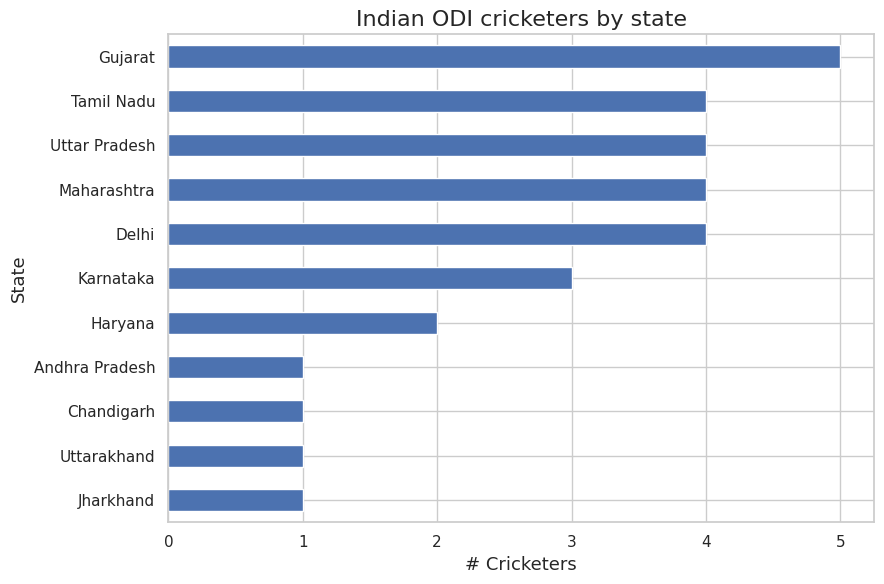

In [16]:
# Players per state
plt.figure()
state_counts.sort_values().plot(kind="barh", title="Indian ODI cricketers by state")
plt.xlabel("# Cricketers")
plt.tight_layout()
plt.show()

### Distribution of Player Roles

Plot a horizontal bar chart telling us how many ODI cricketers fall into each playing role.

---

#### 1  `plt.figure()`

* *“Give me a clean sheet of paper.”*
  We open a brand-new matplotlib figure so this plot doesn’t overlap any earlier ones.

---

#### 2  `sns.countplot(y="role", data=df, order=role_counts.index)`

* **`sns.countplot`** – Seaborn’s quick helper for “how many of each category?”
* **`y="role"`** – Put the **role names** (Batsman, Bowler, …) down the **Y-axis**.
  Counts will automatically go on the X-axis.
* **`data=df`** – Use our main DataFrame as the source.
* **`order=role_counts.index`** – Show the roles in the exact order we already calculated (`role_counts`), which is usually highest count first. That keeps the bars neatly sorted.

---

#### 3  `plt.title("Distribution of player roles")`

* Adds a descriptive title on top so everyone knows what the bars represent.

---

#### 4  `plt.tight_layout()`

* Auto-adjust spacing so labels, ticks, and the title don’t bump into the edges of the figure.

---

#### 5  `plt.show()`

* *“Okay, display the picture.”*
  In a notebook it pops up right below the cell; in a plain script it opens a window.

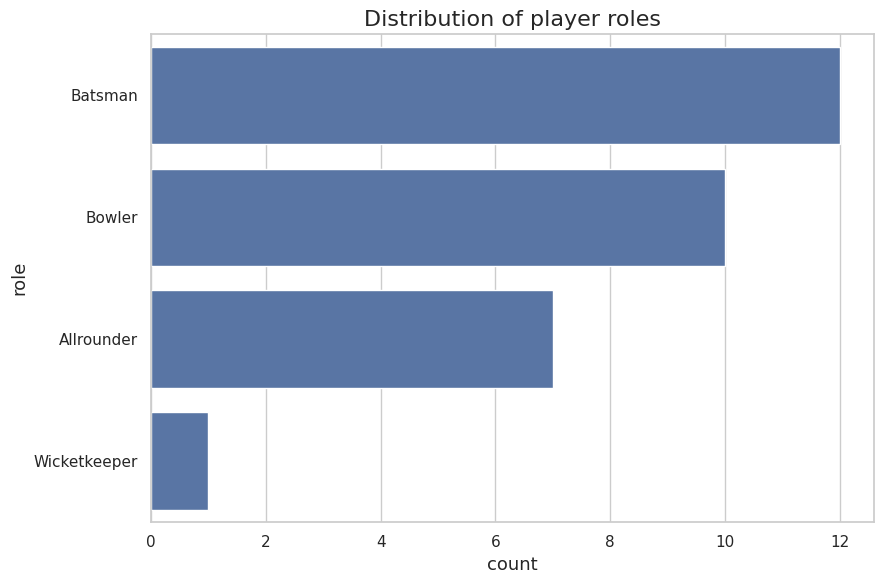

In [17]:
plt.figure()
sns.countplot(y="role", data=df, order=role_counts.index)
plt.title("Distribution of player roles")
plt.tight_layout()
plt.show()

### Population vs No of players (scatter)

Compare each state’s typical city size (on a log scale) with how many ODI cricketers it produces, then label the dots so everyone can spot patterns at a glance.

---

```python
plt.figure()
```

**“Start with a fresh canvas.”**
We open a brand-new Matplotlib figure so this plot doesn’t collide with earlier charts.

---

```python
state_pop = df.groupby("State")["population"].mean()
```

1. **`df.groupby("State")`** – Gather all rows that belong to the same state.
2. **`["population"].mean()`** – For each state group, take the **average** population value.
   *Result:* one number per state ⇒ “typical city size” for that state.

---

```python
state_player_counts = df.groupby("State")["Player_name"].count()
```

1. Group by state again.
2. **`["Player_name"].count()`** – Count how many players each state supplies.
   *Result:* one number per state ⇒ “number of ODI cricketers.”

---

```python
plt.scatter(state_pop, state_player_counts)
```

**“Plot the dots.”**

* X-axis → average city population of the state.
* Y-axis → number of players from that state.
  Each dot = one state.

---

```python
for state in state_pop.index:
    plt.text(state_pop[state],
             state_player_counts[state] + 0.05,  # nudge text above the dot
             state,
             fontsize=9)
```

**“Label every dot with its state name.”**

* Loop through each state.
* Place the name slightly above its point so labels don’t sit on top of the dots.

---

```python
plt.xscale("log")
```

**“Switch the X-axis to a log scale.”**
Big populations (millions) and small ones sit together more comfortably when you compress the scale exponentially.

---

```python
plt.xlabel("State capital average city population (log scale)")
plt.ylabel("Number of players from state")
```

Clear axis labels: what the numbers on each axis mean.

---

```python
plt.title("Do more populous states produce more ODI cricketers?")
```

A question-style title that tells viewers what relationship we’re testing.

---

```python
plt.tight_layout()
```

Automatic spacing tweak so nothing overlaps frame edges.

---

```python
plt.show()
```

**“All set—draw the chart.”**
Jupyter renders it below the cell; a script opens a window.

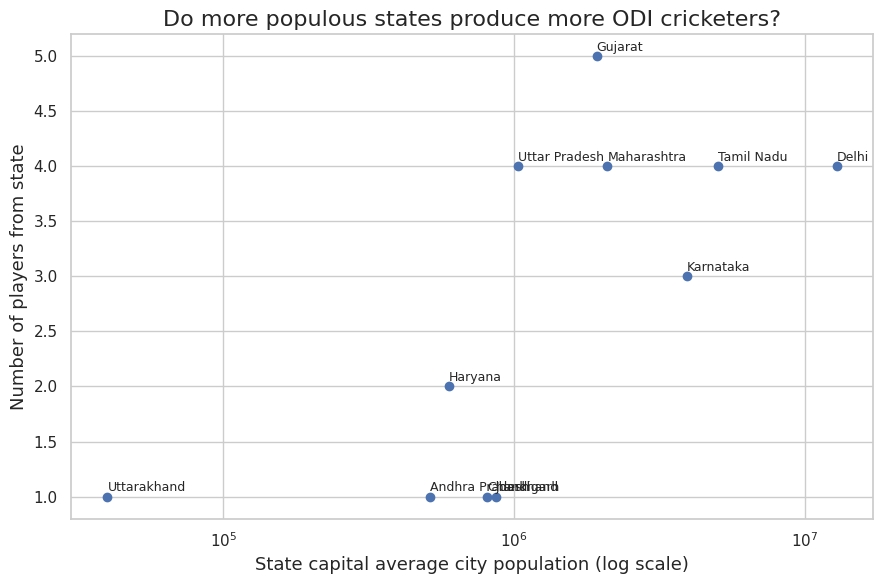

In [18]:
plt.figure()
state_pop = df.groupby("State")["population"].mean()
state_player_counts = df.groupby("State")["Player_name"].count()
plt.scatter(state_pop, state_player_counts)
for state in state_pop.index:
    plt.text(state_pop[state], state_player_counts[state]+0.05, state, fontsize=9)
plt.xscale("log")
plt.xlabel("State capital average city population (log scale)")
plt.ylabel("Number of players from state")
plt.title("Do more populous states produce more ODI cricketers?")
plt.tight_layout()
plt.show()

### Age vs ODIs scatter with regression

These five lines create a scatter-plot of age vs. ODI appearances, add a regression line to show the overall trend, title it, tidy the spacing, and finally draw the chart for everyone to see.

---

#### `plt.figure()`

*“Give me a clean sheet of paper.”*
We open a brand-new Matplotlib figure so whatever we draw next doesn’t get mixed up with earlier plots.

---

#### `sns.regplot(x="age_today", y="odis_played", data=df)`

1. **`sns.regplot`** – Seaborn’s quick tool for drawing a scatter-plot **plus** a trend line.
2. **`x="age_today"`** – Put each player’s current age on the **X-axis**.
3. **`y="odis_played"`** – Put the number of ODIs they’ve played on the **Y-axis**.
4. **`data=df`** – Tell Seaborn to look inside our DataFrame `df` for those two columns.

Result: every dot is one player; Seaborn also fits a simple straight line through the cloud of dots so we can eyeball whether “older” usually means “more ODIs.”

---

#### `plt.title("Is age (proxy for experience) related to ODIs played?")`

Adds a clear, question-style title so viewers know what relationship we’re exploring.

---

#### `plt.tight_layout()`

Automatic spacing tweak. It nudges labels, ticks, and the title so nothing crashes into the edges of the figure.

---

#### `plt.show()`

*“All set—display the picture.”*
In a Jupyter notebook the chart pops up right below the code cell. In a plain script it opens a window.

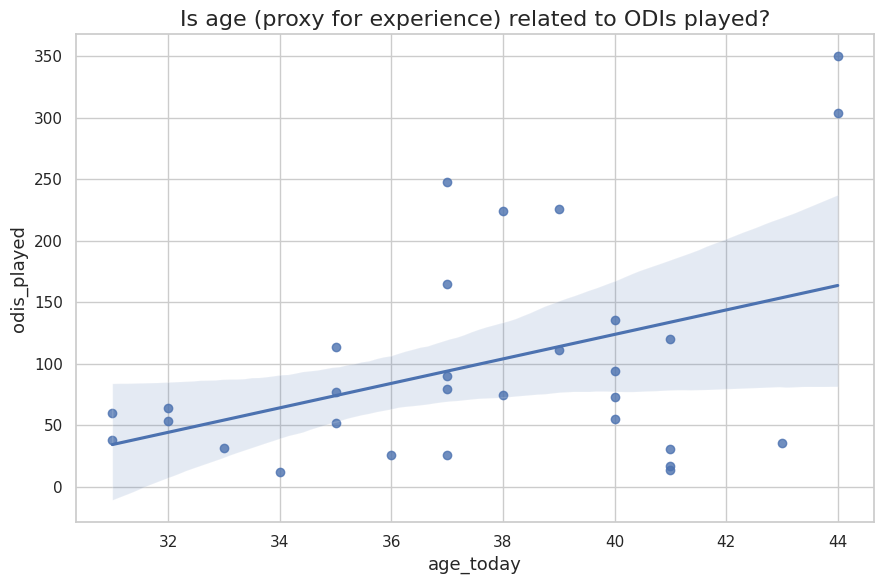

In [19]:
# Age vs ODIs scatter with regression
plt.figure()
sns.regplot(x="age_today", y="odis_played", data=df)
plt.title("Is age (proxy for experience) related to ODIs played?")
plt.tight_layout()
plt.show()

### Pareto & Cumulative Curve

Create a table where every row should tell:

1. The player’s ODI count.
2. The cumulative ODIs up to that player (`cum_odis`).
3. How much of the total ODI pie that cumulative number represents (`cum_pct`).
4. What fraction of all players we’ve counted so far (`player_pct`).

Perfect for drawing a Pareto (80-20) curve.

---

####  `df_sorted = df.sort_values("odis_played", ascending=False)`

* *“Take our whole data table (`df`) and sort it so the players with the **most ODIs** come first.”*
* `ascending=False` means highest to lowest.
* The sorted copy is saved as `df_sorted`.

---

####  `df_sorted["cum_odis"] = df_sorted["odis_played"].cumsum()`

* *“Create a new column called `cum_odis`.”*
* `.cumsum()` walks down the `odis_played` column, **adding as it goes**—so each row shows the running total of ODIs up to that player.

---

####  `total_odis = df_sorted["odis_played"].sum()`

* *“Add up the entire `odis_played` column once to get the **grand total** of ODIs for all players.”*
* Store that number in `total_odis` for later use.

---

####  `df_sorted["cum_pct"] = df_sorted["cum_odis"] / total_odis * 100`

* *“Convert the running totals into **percentages** of the grand total.”*
* Divide each `cum_odis` by `total_odis`, then multiply by 100 so we get 0 – 100 %.

---

####  `df_sorted["player_pct"] = np.arange(1, len(df_sorted) + 1) / len(df_sorted) * 100`

* `np.arange(1, len(df_sorted) + 1)` creates the sequence **1, 2, 3, …** up to the number of players.
* Divide each position by the total player count, multiply by 100 → **“What percent of players have we listed so far?”**
* Store that in `player_pct`.


In [20]:
# --------------------- Pareto & cumulative curve -----------------------
df_sorted = df.sort_values("odis_played", ascending=False)
df_sorted["cum_odis"] = df_sorted["odis_played"].cumsum()
total_odis = df_sorted["odis_played"].sum()
df_sorted["cum_pct"] = df_sorted["cum_odis"] / total_odis * 100
df_sorted["player_pct"] = np.arange(1, len(df_sorted) + 1) / len(df_sorted) * 100

### Plot Cumulative Curve

1. Plot the cumulative-percentage curve with dots.
2. Add a horizontal dashed line at the 80 % level.
3. Drop a vertical dashed line where the curve first meets that 80 %. Together, these two guides instantly reveal the 80-20 (or 85-15, etc.) relationship in the data.

---

#### `plt.plot(df_sorted["player_pct"], df_sorted["cum_pct"], marker="o", linestyle="-")`

* **`plt.plot(`** – “Draw a line (and optionally points) on our current figure.”
* **`df_sorted["player_pct"]`** – X-values: *“What percent of players have we counted so far?”*
  (1 %, 2 %, … 100 %).
* **`df_sorted["cum_pct"]`** – Y-values: *“What percent of all ODI appearances do those players account for?”*
* **`marker="o"`** – Put a small circle (\●) at every data point so the curve’s bends are easy to see.
* **`linestyle="-"`** – Connect the dots with a solid line.

*Result:* the classic **Pareto curve** that climbs from (0 %, 0 %) to (100 %, 100 %).

---

#### `plt.axhline(80, color="gray", linestyle="--")`

* **`plt.axhline(`** – “Add a *horizontal* reference line across the plot.”
* **`80`** – Place it at y = 80 %.
* **`color="gray", linestyle="--"`** – Draw it as a thin grey dashed line.

*Purpose:* a visual threshold asking, *“Where do we hit 80 % of all ODIs?”*

---

#### `plt.axvline(df_sorted.loc[df_sorted["cum_pct"] >= 80, "player_pct"].min(), color="gray", linestyle="--")`

1. **`df_sorted.loc[df_sorted["cum_pct"] >= 80, "player_pct"]`**

   * Filter the table to rows where the cumulative ODI share has reached or passed 80 %.
   * From those rows, grab the corresponding `player_pct` (x-axis) values.

2. **`.min()`**

   * Pick the **smallest** of those `player_pct` values — that’s the *first* point where the curve crosses 80 %.

3. **`plt.axvline( <that number>, color="gray", linestyle="--")`**

   * “Draw a *vertical* dashed grey line at that x-position.”

*Purpose:* shows what **percentage of players** (e.g., 20 %) are responsible for 80 % of the total ODI appearances.


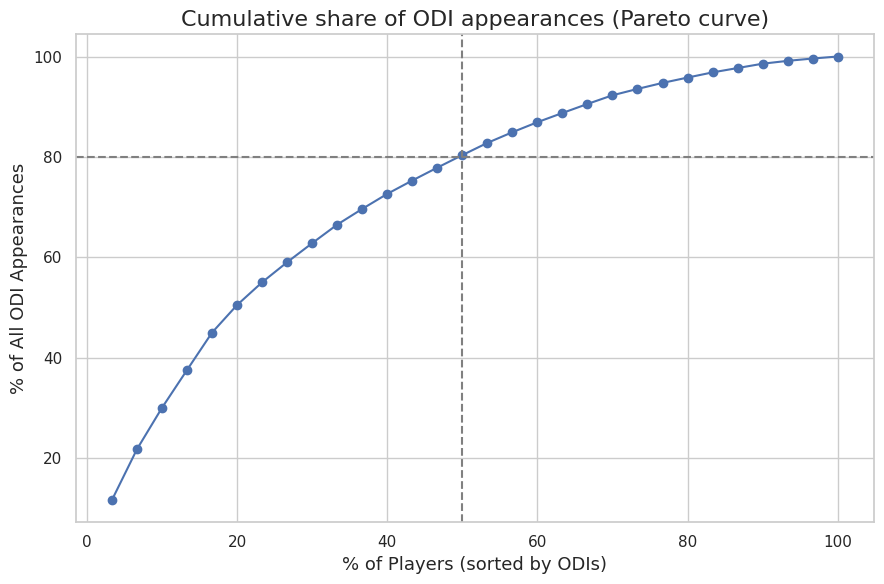

In [21]:
# Plot cumulative curve
plt.figure()
plt.plot(df_sorted["player_pct"], df_sorted["cum_pct"], marker="o", linestyle="-")
plt.axhline(80, color="gray", linestyle="--")
plt.axvline(df_sorted.loc[df_sorted["cum_pct"] >= 80, "player_pct"].min(), color="gray", linestyle="--")
plt.title("Cumulative share of ODI appearances (Pareto curve)")
plt.xlabel("% of Players (sorted by ODIs)")
plt.ylabel("% of All ODI Appearances")
plt.tight_layout()
plt.show()

### Explanation of Pareto Curve

> “Roughly half the players supply four-fifths of India’s ODI appearances—good depth, but the top half still shoulders most of the load; manage their schedules and start grooming the other half now.”

---

#### 1.  What the shape tells us

| Visual cue                                                                   | Plain-English meaning                                                                                                                                         |
| ---------------------------------------------------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Steep rise at the start** (first 10 % of players jump the curve to \~30 %) | A small elite group racks up a lot of appearances.                                                                                                            |
| **Curve is still climbing but flattens out**                                 | Each additional player adds fewer and fewer ODIs to the total.                                                                                                |
| **Horizontal 80 % line meets the curve at ≈ 50 % of players**                | It takes **about half the squad** to deliver 80 % of all appearances. <br> *(So this isn’t the classic 80-20 pattern; workload is spread a bit more evenly.)* |
| **Final point is (100 %, 100 %)**                                            | All players together obviously cover 100 % of matches.                                                                                                        |

---

#### 2.  Quick numeric take-aways

* Rough sketch from the plot:

  * **Top 10 % of players → \~30 % of ODIs**
  * **Top 20 % → \~45 – 50 %**
  * **Top 50 % → 80 %**
* **Gini-style inequality exists** but is moderate: the squad is not totally dependent on a tiny superstar core.

---

#### 3.  Actionable insights for selectors & management

1. **Work-load management**
   *Half the squad is carrying 80 % of the match burden.*
    → Plan rest and rotation for that core 50 % to avoid burnout and injury.

2. **Contract structuring**
   *Contribution is uneven.*
    → Tie retainer tiers and bonus pools to ODI share:
   A-plus contracts for the heavy-load group, development contracts for the long tail.

3. **Talent pipeline & bench depth**
   *Lower half of players see little match time.*
    → Give those fringe players more A-team exposure or high-level domestic fixtures; otherwise the side risks a gap when senior players retire.

4. **Succession planning**
   *If even 10 % of the top contributors retire, ODI coverage drops sharply.*
    → Identify “next-gen” replacements inside that lower 50 % and fast-track their development.

5. **Data-driven selection reviews**
   Re-plot this curve every season. A flattening curve (less steep start) means workload is balancing; a steeper one warns that you’re over-relying on a shrinking core.

### Gini Coefficient (Inequalitiy of ODI appearances)

We built a small helper that calculates the Gini inequality score, applied it to the players’ ODI counts, and printed the answer so we can judge how evenly those matches are distributed across the squad.

---

```python
def gini(array):
```

*“I’m defining a **function** called `gini`.

It will accept one input, which I call `array` (a list or NumPy array of numbers).

When I call this function later, it will give me back a single value: the Gini coefficient.”*

---

```python
    array = np.sort(array)
```

*“First step inside the function: **sort** the numbers from smallest to largest.
Why? The Gini formula expects the data in ascending order.”*

---

```python
    n = len(array)
```

*“Save the **number of items** in the array—call it `n`.
We’ll need that count in the math that comes later.”*

---

```python
    cum = np.cumsum(array)
```

*“`np.cumsum` means *cumulative sum*: it walks down the sorted list, adding as it goes.
So `cum[0]` is just the first number, `cum[1]` is first + second, … all the way to the total at the end.”*

---

```python
    return (n + 1 - 2 * np.sum(cum) / cum[-1]) / n
```

*“Now the heart of the Gini formula, written in one compact line:*

1. **`cum[-1]`** is the very last cumulative sum → the grand total.
2. **`np.sum(cum)`** adds all the cumulative sums together.
3. The rest is a standard algebraic rearrangement of the Gini equation.
4. Finally, `return` hands that single number back to whoever called the function.”

*(No need to memorise the math now; just know it spits out a value between 0 and 1—0 means perfect equality, 1 means total inequality.)*

---

```python
gini_odis = gini(df_sorted["odis_played"].values)
```

*“Outside the function, call `gini` on our real data:*

* **`df_sorted["odis_played"]`** → grab the ODI counts column.
* **`.values`** → convert that Pandas Series to a plain NumPy array (what our function expects).
* **`gini(...)`** returns the coefficient, which we store in `gini_odis`.”

---

```python
print(f"Gini coefficient for ODI appearances: {gini_odis:.3f}")
```

*“Finally, print the result with a friendly message, rounded to three decimal places.”*

*Example output:*

```
Gini coefficient for ODI appearances: 0.37
```

In [22]:
# Gini coefficient (inequality of ODI appearances)
def gini(array):
    array = np.sort(array)
    n = len(array)
    cum = np.cumsum(array)
    return (n + 1 - 2 * np.sum(cum) / cum[-1]) / n

gini_odis = gini(df_sorted["odis_played"].values)
print(f"Gini coefficient for ODI appearances: {gini_odis:.3f}")

Gini coefficient for ODI appearances: 0.445


### How to read a Gini number

* **0.00 = perfect equality** (everyone has exactly the same share)
* **1.00 = perfect inequality** (one person has everything, everyone else has zero)

So the coefficient is really just a *0 – 1* thermometer for “how uneven is the pie?”

#### Your result: **0.445**

1. **Mid-range, leaning unequal**
   *0.445* sits almost halfway between pure equality (0) and pure inequality (1).
   → ODI appearances are **neither evenly spread nor dominated by a single player core**; they’re **moderately concentrated**.

2. **Practical reading for this squad**

   * A noticeable **core group** does the heavy lifting, but
   * the long-tail of players still gets a non-trivial slice of matches.
   * It’s less skewed than a classic “super-star and bench-warmers” pattern (which might score 0.6–0.8).

3. **Actionable ideas**

   * **Workload** – Keep managing rest for that core group, but you’re not in a crisis of over-reliance.
   * **Development** – Players outside the core are already seeing the field; continue rotating them so the Gini doesn’t creep higher.
   * **Succession planning** – Because appearances aren’t ultra-concentrated, the team should handle retirements better than a high-Gini squad would. Still, watch trends: if the coefficient climbs season on season, depth is eroding.

4. **Conversation starter**
   “Our ODI workload inequality is at 0.45—healthy but worth watching. Let’s aim to keep it in the 0.35–0.45 band by giving fringe players targeted series whenever the schedule allows.”

In short, **0.445 means a moderate, manageable imbalance**: a clear first-choice group plays more games, but opportunities are shared widely enough to keep the bench match-ready.


### Role and State Heatmap

```python
role_state = pd.crosstab(df["State"], df["role"])
```

**Step-by-step explanation**

1. **`df["State"]`**
   *“Take the **State** column from our main DataFrame. Each entry is the state a player comes from.”*

2. **`df["role"]`**
   *“Now grab the **role** column—Batsman, Bowler, All-rounder, etc.”*

3. **`pd.crosstab( … )`**
   *“Feed those two columns into **pandas’ crosstab** function.”*

   * Crosstab builds a **two-way frequency table** (also called a contingency table).
   * Rows = unique states, columns = unique roles.
   * Each cell counts how many players fall into that state-and-role combination.

4. **`role_state =`**
   *“Save the resulting table in a new variable called `role_state` so we can print or plot it later.”*

After this single line runs, `role_state` looks something like:

```
role        All-rounder  Batsman  Bowler  Wicket-keeper
State                                                  
Karnataka            3        5       2              1
Maharashtra          2        6       4              0
Tamil Nadu           1        3       3              2
…                   …        …       …              …
```

Now we have an instant snapshot of **which roles dominate which states**, now we can use the remaining code to develop heat-maps for further analysis.


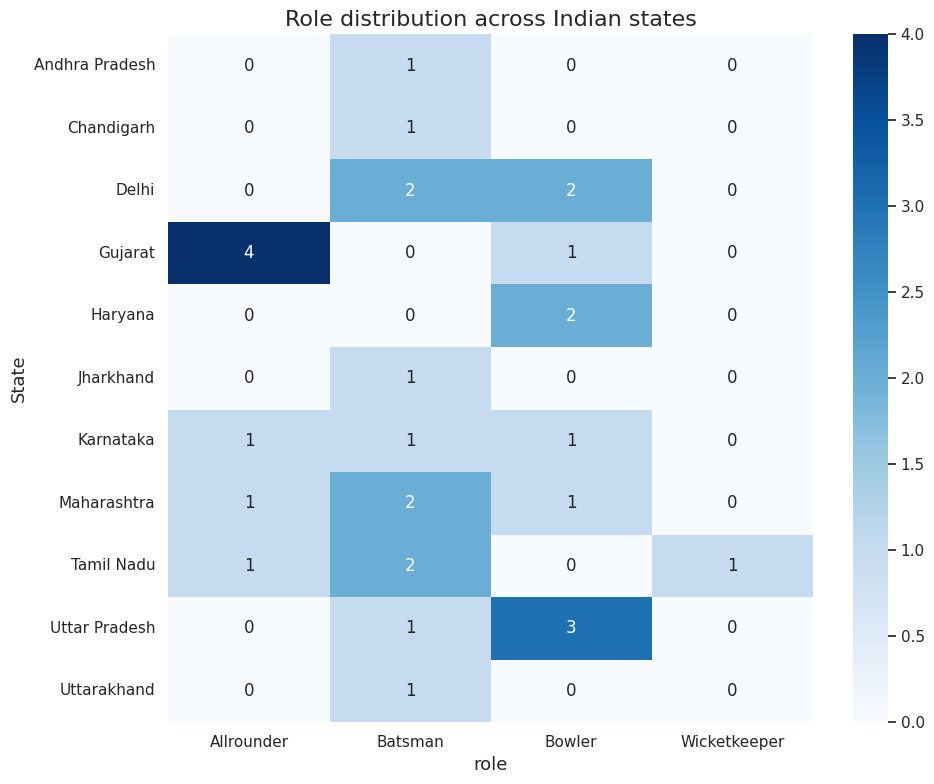

In [23]:
# ----------------------- Role × State heat‑map -------------------------
role_state = pd.crosstab(df["State"], df["role"])
plt.figure(figsize=(10, 8))
sns.heatmap(role_state, annot=True, fmt="d", cmap="Blues")
plt.title("Role distribution across Indian states")
plt.tight_layout()
plt.show()

### Reading the heat-map

> *India’s ODI talent pipeline shows clear regional role hubs—Gujarat for all-rounders, UP/Haryana for bowlers, TN for keepers—great for specialisation, but selectors must expand keeper scouting and encourage more balanced role development in single-track states to keep the national bench deep and resilient.*

---

#### Detailed Explanation

* Each **row** is a state.
* Each **column** is a player role.
* Numbers and darker blue mean “more cricketers in that role.”

Quick count snapshot (values taken directly from the chart):

| State                                           | All-rounder | Batsman | Bowler | Wicket-keeper |
| ----------------------------------------------- | ----------- | ------- | ------ | ------------- |
| Gujarat                                         | **4**       | 0       | 1      | 0             |
| Uttar Pradesh                                   | 0           | 1       | **3**  | 0             |
| Delhi                                           | 0           | 2       | 2      | 0             |
| Haryana                                         | 0           | 0       | 2      | 0             |
| Tamil Nadu                                      | 1           | 2       | 0      | **1**         |
| Karnataka                                       | 1           | 1       | 1      | 0             |
| Maharashtra                                     | 1           | 2       | 1      | 0             |
| Others (AP, Chandigarh, Jharkhand, Uttarakhand) | 0           | 1       | 0      | 0             |

---

### Key inferences

1. **Role specialisation by state**

| State | Clear strength |
|-------|----------------|
| **Gujarat** | Produces far more **all-rounders** (4) than anyone else |
| **Uttar Pradesh** | Skewed heavily toward **specialist bowlers** (3) |
| **Haryana** | Also bowler-focused (2) with zero batsmen/all-rounders |
| **Tamil Nadu** | Only state supplying a **wicket-keeper** in this sample; batting-heavy, no bowlers |
| **Delhi** | Balanced output—equal count of batsmen and bowlers |
| **Karnataka & Maharashtra** | Broad mix but at low counts |



2. **Batsmen are the most geographically widespread role.**
   Almost every state registers at least one batsman.

3. **Wicket-keepers are scarce.**
   Only one appears (Tamil Nadu), hinting at a potential depth problem.

4. **Several states look one-dimensional.**
   Gujarat (mostly all-rounders), UP/Haryana (mostly bowlers), Tamil Nadu (batting + keeping, no bowlers) could become vulnerable if that pipeline dries up.

---

### Actionable insights for selectors & academies

| Area                                   | Recommendation                                                                                                                                                                                    | Why the plot supports it                                       |
| -------------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- | -------------------------------------------------------------- |
| **Targeted scouting**                  | **Widen wicket-keeper search beyond Tamil Nadu.**                                                                                                                                                 | Only one keeper in the dataset—depth risk.                     |
| **Role-specific academies**            | • **All-rounder centre in Gujarat** (already a proven nursery).<br>• **Pace/spin academy in UP & Haryana** for bowling talent.<br>• **Keeping school in TN** but start satellite camps elsewhere. | Leverage existing strengths while diversifying supply.         |
| **Balanced squad building**            | Don’t over-select bowlers from UP/Haryana or all-rounders from Gujarat alone; mix states to avoid role redundancy.                                                                                | Prevents regional over-dependence highlighted by the heat-map. |
| **State-level development programmes** | Help one-dimensional states round out skills—e.g., introduce specialised bowling coaching in Tamil Nadu and batting clinics in Gujarat.                                                           | Raises floor talent and spreads load across roles.             |
| **Performance monitoring**             | Re-generate this heat-map every domestic season to track whether investments broaden or narrow role diversity.                                                                                    | Quick visual check for pipeline health.                        |

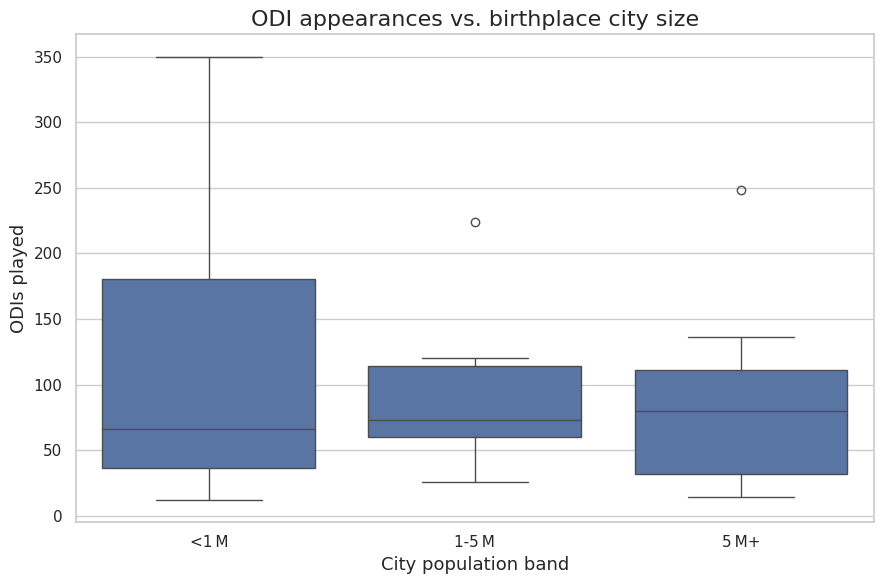

In [24]:
# ----------------------- City‑size impact ------------------------------
plt.figure()
sns.boxplot(x="city_size", y="odis_played", data=df, order=labels)
plt.title("ODI appearances vs. birthplace city size")
plt.xlabel("City population band")
plt.ylabel("ODIs played")
plt.tight_layout()
plt.show()

### Analysis of Box-Plot

*Birthplace population doesn’t dictate ODI longevity—great players come from villages as well as metros—so scouting and development must stay nationwide, with extra support to turn volatile small-town potential into consistent international output.*

---

| City-size band                | Median ODIs (middle line) | Spread (box & whiskers)                                      | Notable outliers                                                |
| ----------------------------- | ------------------------- | ------------------------------------------------------------ | --------------------------------------------------------------- |
| \*\* < 1 M\*\* (small towns)  | roughly **60–70 matches** | Widest range: some play just a handful, a few reach **350+** | One player dominates the left-hand tail with a very long career |
| **1 – 5 M** (mid-size cities) | \~ 70 matches             | Tighter cluster around the median; maximum ≈ 225             | One obvious high-flyer                                          |
| **5 M +** (mega-cities)       | \~ 80 matches             | Similar IQR to mid-size, upper whisker ≈ 135                 | Outlier near 250                                                |


1. **No big city advantage in median career length**
   The middle of each box sits at roughly the same height, so typical ODI totals are similar whether a player is born in a small town, a mid-size city, or a mega-city.

2. **Greater volatility for small-town players**
   The small-town band shows both the lowest lows and the highest highs. Some never break in, a few go on to very long runs.

3. **Mega-city cricketers are more “middle-of-the-pack”**
   Careers from the largest cities appear more consistent—fewer extremely short or extremely long ODI totals.

4. **Star talent emerges from **all** city sizes**
   The lone outliers in every band prove elite careers aren’t confined to one demographic bucket.

---

### Actionable insights for selectors & academies

| Decision area            | Recommendation                                         | Rationale from the plot                                                                                                                    |
| ------------------------ | ------------------------------------------------------ | ------------------------------------------------------------------------------------------------------------------------------------------ |
| **Scouting focus**       | **Keep (or expand) talent hunts in small towns.**      | They produce some of the longest-serving internationals; ignoring them risks missing the next superstar.                                   |
| **Development pathways** | **Stabilise small-town prospects.**                    | Wide spread hints at inconsistent support: set up better coaching, fitness, and transition programmes so more of them reach their ceiling. |
| **Resource allocation**  | **Maintain balanced investment across city tiers.**    | Median output is similar everywhere; pouring resources into mega-cities alone will not raise the average ODI tally.                        |
| **Benchmark targets**    | **Aim for \~70–80 ODIs as a “healthy career” marker.** | That’s where the medians cluster across bands; use it to set KPIs for player retention and workload planning.                              |
| **Monitoring & review**  | **Track this box-plot each cycle.**                    | Sudden changes in spread or median can reveal if one pipeline is faltering or if workload equity is drifting.                              |

### Age Cohart Trend


1. **Slice** every birth year into neat 5-year bands (1960–64, 1965–69, …).
2. **Add** those band labels to the DataFrame as `birth_cohort`.
3. **Group** by those labels and **count** players to see which eras produced the most talent.


These two code blocks as one little **lesson on binning and grouping**.

---

```python
df["birth_cohort"] = pd.cut(
    df["birth_year"],
    bins=np.arange(df["birth_year"].min() // 5 * 5, CURRENT_YEAR, 5),
    right=False,
)
```

#### 1. `df["birth_cohort"] = …`

*“We’re about to **add a brand-new column** to the DataFrame and name it `birth_cohort`.”*
Every row will soon hold a label like *1985–1989* or *1990–1994*.

---

#### 2. `pd.cut(`

*“Use Pandas’ **cut** function to slice a numeric series into labelled buckets.”*

---

#### 3. `df["birth_year"],`

*“Feed in the entire **birth\_year** column. That’s what we’re going to bucket.”*

---

#### 4. `bins=`

*“Tell `cut` exactly where each bucket starts and ends.”*

```python
np.arange(df["birth_year"].min() // 5 * 5, CURRENT_YEAR, 5)
```

*Breakdown of this mini-formula:*

| Piece                       | Spoken explanation                                                                                   |
| --------------------------- | ---------------------------------------------------------------------------------------------------- |
| `df["birth_year"].min()`    | “Find the **earliest** birth year in the data set.”                                                  |
| `// 5 * 5`                  | “Round that year **down** to the nearest multiple of 5.”<br>(e.g. 1987 → 1985)                       |
| `CURRENT_YEAR`              | “The upper limit—usually today’s year—pulled from the variable we set earlier.”                      |
| `np.arange(start, stop, 5)` | “Make a sequence that goes *start, start+5, start+10, …* up to but **not including** the stop year.” |

So if the earliest birth year is 1963 and `CURRENT_YEAR` is 2025, the bins list will be
`[1960, 1965, 1970, … , 2020]`.

---

#### 5. `right=False,`

*“Make each interval **left-inclusive, right-exclusive**.”*
Example: The bin *1985–1990* will include 1985, 1986, … 1989, but **not** 1990 (that starts the next bin). This avoids double-counting boundary years.

---

#### 6. *end of `pd.cut`*

`pd.cut` returns a **categorical Series**—one cohort label for every player—which we save in `df["birth_cohort"]`.

---

```python
cohort_counts = df.groupby("birth_cohort")["Player_name"].count()
```

#### 7. `df.groupby("birth_cohort")`

*“Group all rows that share the same 5-year cohort.”*

#### 8. `["Player_name"].count()`

*“Within each group, **count** how many players there are.”*
We use `Player_name` just to pick any non-null column; counting names equals counting rows.

#### 9. `cohort_counts = …`

*“Store that result in `cohort_counts`. It’s now a tidy list that tells us, for every 5-year birth window, how many ODI cricketers were born.”*

<ipython-input-25-296659cebc2d>:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cohort_counts = df.groupby("birth_cohort")["Player_name"].count()


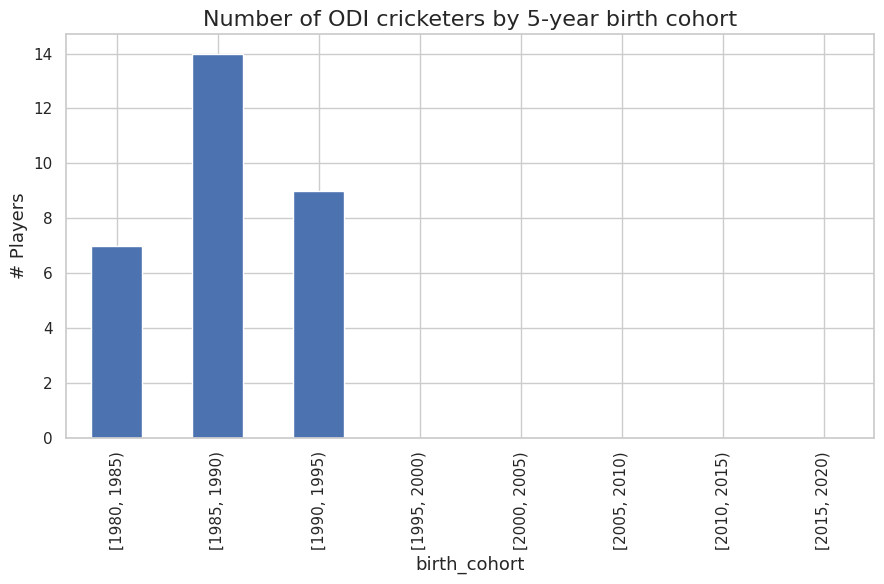

In [25]:
# ----------------------- Age cohort trend ------------------------------
df["birth_cohort"] = pd.cut(
    df["birth_year"],
    bins=np.arange(df["birth_year"].min() // 5 * 5, CURRENT_YEAR, 5),
    right=False,
)
cohort_counts = df.groupby("birth_cohort")["Player_name"].count()
plt.figure()
cohort_counts.plot(kind="bar")
plt.title("Number of ODI cricketers by 5‑year birth cohort")
plt.ylabel("# Players")
plt.tight_layout()
plt.show()

### Interpretation

> *A late-80s birth cohort forms the backbone of the current ODI side; without stronger representation from players born after 1994, the team risks an experience cliff in the near future—youth development and updated data tracking should be top priorities.*

---

1. **Birth-years 1985–1989 dominate the dataset**
   – That single five-year band produced **14 players**, the largest block on the chart.

2. **The cohort immediately before (1980–1984) and after (1990–1994) taper off**
   – 7 players born 1980-84
   – 9 players born 1990-94
   – So there’s a sharp “bulge” centred on the late-80s.

3. **No recorded players born after 1994**
   – Every bin from 1995 onward is empty.
   – Either the dataset stops there (more recent debuts not yet included) **or** the current pipeline hasn’t delivered ODI-level players from those younger age groups.

---

### Practical implications & next steps

| Issue spotted                                                      | Why it matters                                                                                            | Action you’d recommend                                                                                                                                                                                 |
| ------------------------------------------------------------------ | --------------------------------------------------------------------------------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------ |
| **Ageing talent core** – Late-80s cohort is now mid-30s (in 2025). | Many of those players are approaching the back end of their careers; sudden retirements could leave gaps. | Begin phased succession planning: identify two replacements for every key position held by a 35-plus player.                                                                                           |
| **Dip in early-90s numbers**                                       | Smaller follow-up cohort means less built-in depth when the ’85-89 group retires.                         | Intensify high-performance support for the ’90-94 cohort so they can shoulder more matches in the next 3-5 years.                                                                                      |
| **Missing younger cohorts (post-1995)**                            | If the data is complete, the youth pipeline into ODIs is weak.                                            | • Audit domestic structures: are promising U-23 players graduating?<br>• Expand A-team tours and “Emerging Players” programmes.<br>• Increase scouting and academy scholarships for 18–24 age bracket. |
| **Data completeness**                                              | Empty bins might simply mean the CSV was limited.                                                         | Cross-check with the latest BCCI or ICC roster; update the dataset and rerun the plot annually.                                                                                                        |


### City-Size by Role Facet

Three side-by-side box-plots (one per city-size band) that
let us compare how ODI counts vary by playing role and birthplace
population.


```python
g = sns.catplot(
```

**“Start a Seaborn *categorical plot* and store the whole thing in a
variable called `g`.”**
We’ll use `g` later to tweak the figure.

---

```python
    data=df,
```

*“Work with our main DataFrame called `df`.”*
Every other argument will look for columns inside this table.

---

```python
    x="role",
```

*“On the horizontal axis put the column **`role`**:
Batsman, Bowler, All-rounder, Wicket-keeper.”*

---

```python
    y="odis_played",
```

*“On the vertical axis plot **`odis_played`** – how many ODIs each player has played.”*

---

```python
    col="city_size",
```

*“Instead of one big plot, make **separate panels** (columns) for each
`city_size` bucket (1 M, 1-5 M, 5 M+).”*

That’s called *faceting*.

---

```python
    kind="box",
```

*“Draw **box-plots** (median line, quartiles, whiskers, outliers) for
each role in every city-size panel.”*
Good for comparing distributions.

---

```python
    order=sorted(df["role"].unique()),
```

*“Force the roles to appear in a consistent left-to-right order.”*
We sort the unique role names alphabetically so the same sequence
appears in every facet.

---

```python
    col_order=labels,
```

*“Show the city-size panels in the order stored in the list
`labels` (we defined it earlier as `["<1 M", "1-5 M", "5 M+"]`).”*

---

```python
    sharey=False,
```

*“Let each facet have its **own y-axis scale**.”*
If one city-size band has very tall boxes, it won’t squash the others.

---

```python
    height=4,
    aspect=1
```

*“Set each small subplot to be 4 inches tall and perfectly square
(aspect ratio = 1).”*

---

```python
)
```

*“Close the `catplot` call.”*
At this point the multi-panel figure is created and stored in `g`.

---

```python
g.fig.subplots_adjust(top=0.8)
```

*“Nudge the whole grid **down** a bit, leaving 20 % of the canvas free
at the top for a big title.”*

---

```python
g.fig.suptitle("Role-wise ODI appearances stratified by city size")
```

*“Add that big, centred title we just made room for.”*

---

```python
plt.show()
```

*“Finally, display the figure on screen.”*
In a Jupyter notebook it appears right below the cell; in a script a
window pops up.

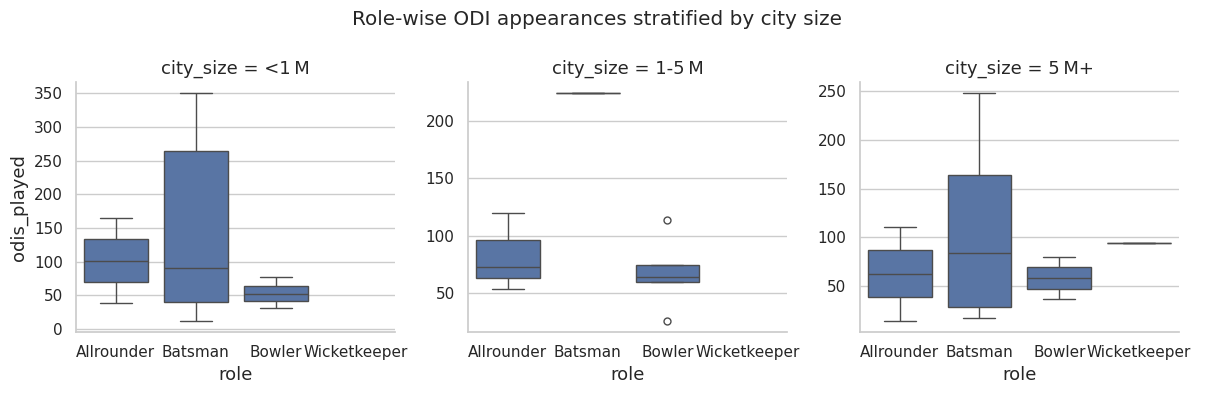

In [26]:
# ----------------------- City‑size by Role facet -----------------------
g = sns.catplot(
    data=df,
    x="role",
    y="odis_played",
    col="city_size",
    kind="box",
    order=sorted(df["role"].unique()),
    col_order=labels,
    sharey=False,
    height=4,
    aspect=1
)
g.fig.subplots_adjust(top=0.8)
g.fig.suptitle("Role‑wise ODI appearances stratified by city size")
plt.show()

### Three-panel box-plot Explanation

*Career length varies more by **role** than by birthplace size, but small-town batting stars and mega-city wicket-keepers illustrate city-specific pipelines; targeted coaching, injury management, and broader scouting can smooth these imbalances and secure a deeper national bench.*

---

| Facet                   | Quick visual reading                                                                                                                                  | Key numbers (approx.)                                                       |
| ----------------------- | ----------------------------------------------------------------------------------------------------------------------------------------------------- | --------------------------------------------------------------------------- |
| **< 1 M** birthplaces   | Batsmen have the **widest career spread** (a few play < 10 ODIs, one reaches **350+**). All-rounders cluster around 90 ODIs. Bowlers top out near 80. | Median ODIs → All-rounder ≈ 90 · Batsman ≈ 80 · Bowler ≈ 50                 |
| **1 – 5 M** birthplaces | Batsmen form a **tight high cluster** around 220 ODIs (one clear stand-out). All-rounders and bowlers sit lower (60-110).                             | Median ODIs → Batsman ≈ 220 · All-rounder ≈ 80 · Bowler ≈ 70                |
| **5 M +** birthplaces   | Every role’s spread is moderate; wicket-keepers appear **only here** and hover just below 100 ODIs. Batsmen again show a long tail up to 250.         | Median ODIs → W-keeper ≈ 95 · Batsman ≈ 90 · All-rounder ≈ 75 · Bowler ≈ 60 |

*(Exact figures depend on the underlying data; these are eyeball estimates from the plot.)*

---

### Inferences

1. **Batsmen enjoy the longest ODI careers regardless of city size** – their median and upper-whisker values consistently beat bowlers and all-rounders.

2. **Small-town (< 1 M) batsmen are boom-or-bust** – some barely debut, but a few become marathon players (350+ ODIs).  Greater variance hints at uneven support structures.

3. **Mid-size cities (1 – 5 M) produce fewer batsmen, but when they break through they stay** – tight, high box suggests consistent backing once selected.

4. **Mega-city (5 M +) wicket-keepers dominate that role** – no keepers appear in smaller-town panels.  Pipeline for this specialist skill seems restricted to large urban centres.

5. **Bowlers have the lowest medians across all city tiers** – possibly due to higher physical attrition or rotation policies.

---

### Actionable insights for talent programmes & selectors

| Decision area                 | Recommended action                                                                                                                       | Why the plot points that way                                                                                                  |
| ----------------------------- | ---------------------------------------------------------------------------------------------------------------------------------------- | ----------------------------------------------------------------------------------------------------------------------------- |
| **Small-town batting talent** | • Strengthen coaching and sports-science support in < 1 M centres.<br>• Provide consistent A-team exposure early.                        | High variance shows potential super-stars, but many fade quickly.  Bridging facilities can convert volatility into longevity. |
| **Bowler career extension**   | • Invest in injury-prevention and workload management across all city sizes.                                                             | Bowlers’ lower medians suggest shorter careers; better support could lift that curve.                                         |
| **Wicket-keeper depth**       | • Launch keeper-specific academies in mid-size and small cities.<br>• Run nationwide trials.                                             | Currently confined to mega-cities; risk of single-pipeline dependency.                                                        |
| **Mid-size city scouting**    | • Keep an eye on mid-size centres for “ready-made” batsmen who adapt quickly to international level.                                     | Tight, high box in 1-5 M facet shows a reliable stream of long-career batsmen.                                                |
| **Role-balanced squads**      | • When selecting from small towns, consciously add extra bowling options; when selecting from UP-scale metros, check for balanced roles. | Ensures diversity of skill-sets given each city-size band’s bias.                                                             |

---



### Correlation

We list the numeric columns we care about, tell Pandas to compute the Pearson correlation matrix for them, and print the resulting table so we can see how strongly—and in what direction—each pair of variables moves together.

---

**`numeric_cols = ["age_today", "odis_played", "population"]`**

1. We create a small **list** called `numeric_cols`.
2. The list holds the names of three columns in our DataFrame that contain numbers only:

   * `age_today` (the player’s age)
   * `odis_played` (total ODIs)
   * `population` (birth-city population)
3. Collecting the names in one place keeps the next line short and flexible—you can add or remove columns by editing this list.

---

**`corr_matrix = df[numeric_cols].corr()`**

1. `df[numeric_cols]`
   *“Give me **only** those three columns out of the big DataFrame.”*
2. `.corr()`

   * Pandas looks at every pair of columns in that mini-table and calculates the **Pearson correlation coefficient** (a number between –1 and +1).
   * +1 = perfect upward relationship
   * 0 = no linear relationship
   * –1 = perfect downward relationship
3. The result is a **3 × 3 matrix**—each row/column intersection holds the correlation for that pair of variables.
4. We store that matrix in a new variable called `corr_matrix` so we can inspect or plot it later.

---

**`print("\nPearson correlations:\n", corr_matrix)`**

1. `"\n"` at the start makes the printout start on a **new line**.
2. `"Pearson correlations:"` is a heading so you know what you’re looking at.
3. Another `"\n"` adds a blank line for readability.
4. `corr_matrix` prints the actual numbers in tidy matrix form.

In [29]:
# --------------------- Correlation ----------------------
numeric_cols = ["age_today", "odis_played", "population"]
corr_matrix = df[numeric_cols].corr()
print("\nPearson correlations:\n", corr_matrix)



Pearson correlations:
              age_today  odis_played  population
age_today     1.000000     0.415444    0.191774
odis_played   0.415444     1.000000   -0.011954
population    0.191774    -0.011954    1.000000


### Results

> Age gives a rough idea of ODI experience, but birthplace population gives none—so plan rotation and scouting around individual profiles, not city size.

---

#### How to read the numbers

Pearson *r* runs from **+1** (perfect upward link) to **0** (no straight-line link) to **–1** (perfect downward link).

| Pair of variables                       | *r* value | Plain-English meaning                                                                                                                     |
| --------------------------------------- | --------- | ----------------------------------------------------------------------------------------------------------------------------------------- |
| **age ↔ ODIs played**                   | **+0.42** | Moderate upward trend: older players tend to have logged more ODIs, but there are plenty of exceptions.                                   |
| **age ↔ birth-city population**         | +0.19     | Very weak link: a slight tendency for older players to come from bigger cities, but barely noticeable.                                    |
| **ODIs played ↔ birth-city population** | –0.01     | Effectively zero: being born in a mega-city, mid-size city, or small town tells you nothing about how long a player’s ODI career will be. |

*(The diagonals are 1.00 because every column is perfectly correlated with itself.)*

---

### Inferences

1. **Experience still tracks with age, but not rigidly.**
   A 0.42 correlation means age explains only \~18 % of the variation in ODI totals (because *r ² ≈ 0.18*). Some younger players have already piled up lots of matches; some veterans remain fringe picks.

2. **City size is basically irrelevant to career length.**
   With *r ≈ –0.01* between population and ODIs, birthplace population offers no predictive power for how many internationals a player will play.

3. **Slight tilt toward older players from bigger cities—but too small to matter strategically.**
   The +0.19 age-population link could just be historical coincidence (e.g., earlier generations gravitating to metros for coaching).

---

### Actionable insights for selectors & development staff

| Decision                            | Recommended action                                                                                                                 | Why this correlation table supports it                                                                                                                         |
| ----------------------------------- | ---------------------------------------------------------------------------------------------------------------------------------- | -------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Work-load & succession planning** | Keep grooming younger players for key roles **now**; rely on age rather than total ODIs for rest-rotation triggers.                | A moderate age-ODI link means you can roughly gauge mileage by looking at birthdays, but stars who debut young may already need workload management.           |
| **Scouting focus**                  | Maintain or even increase talent searches in **small towns and mid-size cities**.                                                  | Zero correlation between city population and career length shows big metros don’t produce longer-serving players; the return on scouting is location-agnostic. |
| **Analytics dashboards**            | Track age and ODI mileage **separately** in future dashboards.                                                                     | Because the link is only moderate, treating age as a direct proxy for experience will miss both late bloomers and early workhorses.                            |
| **Resource allocation**             | Allocate high-performance resources based on **individual metrics** (fitness, form, injuries) rather than birthplace demographics. | Population adds no explanatory value to ODI counts, so resource spend shouldn’t be biased toward metro-born players.                                           |


### Hypothesis Testing

1. Pull ODI counts for batsmen and all-rounders into two separate lists.
2. Run Welch’s t-test to see if their average match tallies differ.
3. Print the *t* and *p* values so you can decide whether any difference is statistically significant.

---

```python
batsmen_odis = df.loc[df["role"] == "Batsman", "odis_played"]
```

1. **`df.loc[ ... ]`** – Use Pandas’ `.loc` to filter rows.
2. **`df["role"] == "Batsman"`** – Keeps only rows where the `role` column equals `"Batsman"`.
3. **`, "odis_played"`** – After filtering, grab just the `odis_played` column.
4. **`batsmen_odis =`** – Store that one-column Series in a variable called `batsmen_odis`.

---

```python
allrounder_odis = df.loc[df["role"] == "Allrounder", "odis_played"]
```

Exactly the same idea, but this time the filter is `"Allrounder"`.
Result → `allrounder_odis`, another Series of match counts.

---

```python
t_stat, p_val = stats.ttest_ind(batsmen_odis, allrounder_odis, equal_var=False)
```

1. **`stats.ttest_ind( … )`** – Call SciPy’s *independent-samples* t-test.
2. **`batsmen_odis, allrounder_odis`** – Feed in the two groups we just built.
3. **`equal_var=False`** – Tell SciPy *not* to assume equal variances
   (this makes it a Welch’s t-test, safer when the two spreads differ).
4. The function returns two numbers: the **t-statistic** (`t_stat`) and the **p-value** (`p_val`).

---

```python
print(
    f"\nHypothesis test: Are the mean ODIs played different between Batsmen and All-rounders?"
    f"\n    t = {t_stat:.2f}, p = {p_val:.3f}"
)
```

*What the print does, line by line:*

* `\n` – Start on a fresh line.
* First f-string – A heading that states the question we’re testing.
* Second f-string – Indented output showing the numbers,
  formatted to two decimals for *t* and three for *p*.

In [30]:
# Compare ODIs played between Batsmen and All‑rounders
batsmen_odis = df.loc[df["role"] == "Batsman", "odis_played"]
allrounder_odis = df.loc[df["role"] == "Allrounder", "odis_played"]

t_stat, p_val = stats.ttest_ind(batsmen_odis, allrounder_odis, equal_var=False)
print(
    f"\nHypothesis test: Are the mean ODIs played different between Batsmen and All‑rounders?"
    f"\n    t = {t_stat:.2f}, p = {p_val:.3f}"
)


Hypothesis test: Are the mean ODIs played different between Batsmen and All‑rounders?
    t = 1.52, p = 0.149


### Results

> With a p-value of 0.15, the current data say batsmen and all-rounders log roughly the same number of ODIs on average—plan workloads and development paths accordingly, while continuing to monitor future seasons.

---

#### How to read those two numbers

| Statistic | Value | What it means in plain English                                                                                                                                                                      |
| --------- | ----- | --------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| *t*       | 1.52  | The observed gap between the two sample means is about 1.5 “standard-error units” apart. A *t* of ±2 or more usually starts to look interesting.                                                    |
| *p*       | 0.149 | If batsmen and all-rounders **really** had identical average ODI totals, there is a 14.9 % chance we would see a gap this large just by random luck. Typical cut-offs are 5 % (0.05) or 1 % (0.01). |

#### Statistical inference

Because **p = 0.149 > 0.05**, we *fail to reject* the null hypothesis. In everyday language:

> *“We don’t have strong evidence that batsmen and all-rounders differ in the average number of ODIs they play.”*

The sample *could* still hide a true difference, but this test on the current data didn’t reach conventional significance.

#### Caveats to keep in mind

* **Sample size & spread matter.** A small group of all-rounders or very unequal variances can dilute power.
* **Effect size:** Even if a difference were statistically significant, you’d still ask if it is practically large (e.g., 5 matches vs. 50 matches).

#### Actionable insights for coaches & selectors

| Decision area                   | Practical takeaway                                                                                                                                           |
| ------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------ |
| **Work-load policies**          | Manage rest days by *individual mileage*, not by assuming one role is more over-worked than the other.                                                       |
| **Contract tiers & incentives** | No evidence that one role systematically earns more ODIs; base retainer tiers on performance metrics rather than the role label alone.                       |
| **Talent pipeline**             | Since longevity appears similar, prioritise balanced recruitment—don’t shy away from grooming more all-rounders under the assumption they get fewer matches. |
| **Further analysis**            | Re-run the test each season with updated data; a wider or more recent sample may reveal trends (especially if new formats or selection philosophies emerge). |

In [31]:
# -------------------------- 7. Save cleaned data -----------------------------
out_path = Path("odi_cricketers_clean.csv")
df.to_csv(out_path, index=False)
print(f"\nCleaned file written to {out_path.resolve()}")


Cleaned file written to /content/odi_cricketers_clean.csv
